# Housing Price Prediction Project

This project uses machine learning to predict house prices using the California housing dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

## Step 1: Load Dataset

We load the California housing dataset.
This dataset contains features like income, rooms, and location.
Our goal is to predict house prices.

In [2]:
data = fetch_california_housing()

X = data.data
y = data.target

print("Data loaded successfully")
print("Shape:", X.shape)

Data loaded successfully
Shape: (20640, 8)


## Step 2: Convert Data into DataFrame

In [3]:
df = pd.DataFrame(X, columns=data.feature_names)
df["Price"] = y

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Step 3: View Feature Names

In this step, we display the names of all input features in the dataset.
This helps us understand what each column represents.

In [4]:
print(data.feature_names)


['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


## Step 4: Data Visualization

In this step, we visualize the distribution of house prices using a histogram.
This helps us understand how prices are spread in the dataset.

Note: The price values are scaled. 
A value of 1 represents approximately $100,000, 
2 represents $200,000, and so on.

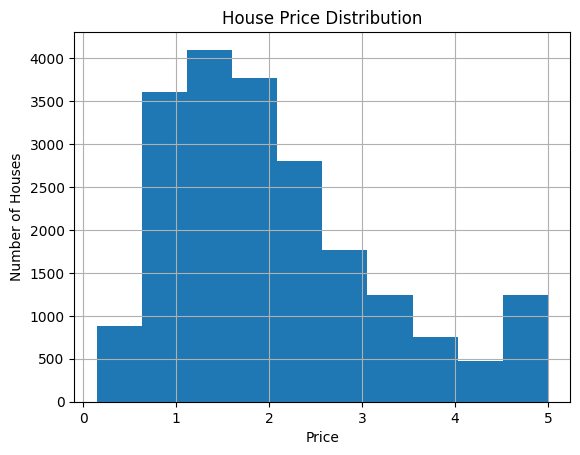

In [5]:
df["Price"].hist()
plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Houses")
plt.show()

## Step 5: Train-Test Split

In this step, we split the dataset into training and testing sets.  
The training data is used to train the model, and the testing data is used to evaluate its performance.

We use 80% of the data for training and 20% for testing.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (16512, 8)
Testing data shape: (4128, 8)


## Step 6: Train the Model (Linear Regression)

In this step, we train a machine learning model using Linear Regression.
The model learns the relationship between input features and house prices.

In [7]:
from sklearn.linear_model import LinearRegression

# create model
model = LinearRegression()

# train model
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Step 7: Make Predictions

In this step, we use the trained model to predict house prices using the test data.
The model will generate predicted values based on learned patterns.


In [8]:
# make predictions
y_pred = model.predict(X_test)

# show first 5 predictions
print("Predicted values:", y_pred[:5])
print("Actual values:", y_test[:5])

Predicted values: [0.71912284 1.76401657 2.70965883 2.83892593 2.60465725]
Actual values: [0.477   0.458   5.00001 2.186   2.78   ]


## Step 8: Evaluate Model Performance

In this step, we evaluate how well the model performs using the R² score.
The R² score measures how close the predicted values are to the actual values.

In [9]:
from sklearn.metrics import r2_score

# calculate accuracy
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.5757877060324521


## Step 9: Feature Scaling (Improvement)

In this step, we apply feature scaling to improve the model performance.
Feature scaling ensures that all input features are on a similar scale,
which helps the model learn more effectively.

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 10: Train Model with Scaled Data

We train the Linear Regression model again using the scaled features.

In [11]:
model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = model_scaled.predict(X_test_scaled)

## Step 11: Evaluate Scaled Model

We evaluate the performance of the model after applying feature scaling.

In [12]:
r2_scaled = r2_score(y_test, y_pred_scaled)
print("R² Score after scaling:", r2_scaled)

R² Score after scaling: 0.5757877060324508


## Step 12: Improve Model using Random Forest

In this step, we use a Random Forest Regressor to improve prediction accuracy.
This model can capture complex relationships in the data.

In [13]:
from sklearn.ensemble import RandomForestRegressor

# create model
rf_model = RandomForestRegressor(random_state=42)

# train model
rf_model.fit(X_train, y_train)

# predict
y_pred_rf = rf_model.predict(X_test)

# evaluate
from sklearn.metrics import r2_score

r2_rf = r2_score(y_test, y_pred_rf)
print("Random Forest R²:", r2_rf)

Random Forest R²: 0.8048502475905297


## Step 13: Model Visualization

In this step, we visualize the relationship between actual and predicted house prices.
This helps us understand how accurate the model predictions are.

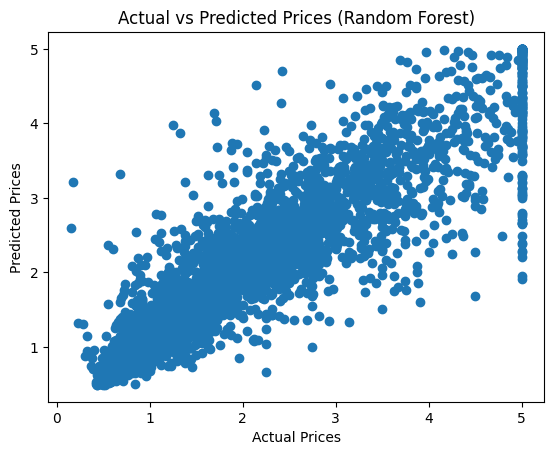

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices (Random Forest)")
plt.show()